Results of observation on supply and demand on market:

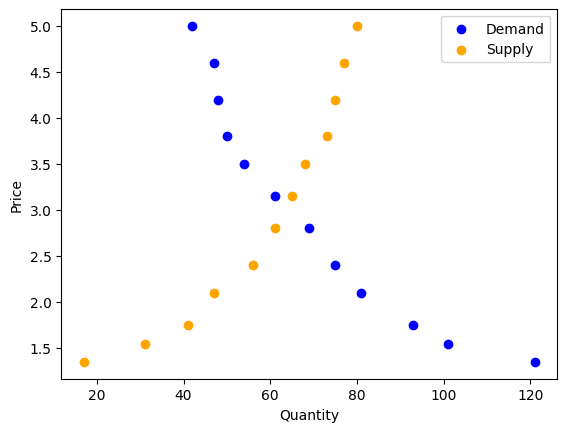

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

df = pd.read_csv("data.csv")

plt.scatter(df["Demand"], df["Price"], color = "blue", label="Demand")
plt.scatter(df["Supply"], df["Price"], color = "orange", label="Supply")

plt.xlabel("Quantity")
plt.ylabel("Price")

plt.legend()
plt.show()

## 1. Analytics function of supply and demand curve
Let's assume that **supply** is logarithmic:
$$P = a e^{b Q}$$
Take the natural log:
$$\ln P = \ln a + b Q$$
Now fit it in linear regression:

a = 0.7970809833185877; b = 0.021667632390556458
P = 0.80 * e^(0.02x)


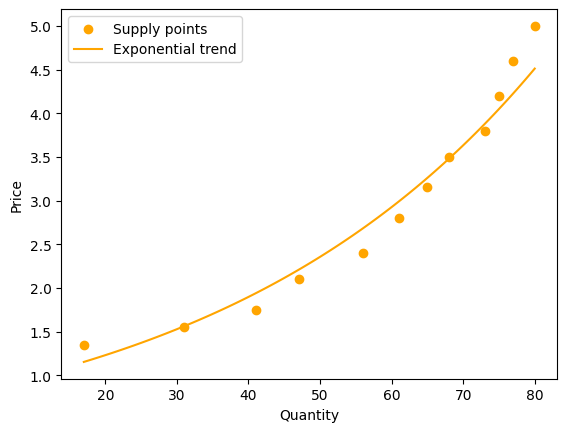

In [3]:
log_P = np.log(df["Price"])
b, log_a = np.polyfit(df["Supply"], log_P, 1)
a = np.exp(log_a)

print(f"a = {a}; b = {b}")
print(f"P = {a:.2f} * e^({b:.2f}x)")

S_range = np.linspace(min(df["Supply"]), max(df["Supply"]), 100)
P_exp = a * np.exp(b * S_range)

plt.scatter(df["Supply"], df["Price"], color = "orange", label="Supply points")
plt.plot(S_range, P_exp, '-', color = "orange", label="Exponential trend")

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.legend()
plt.show()

Analytic function for supply curve is
$$P = 0.8 e^{0.02 Q}$$

Let's assume that **demand** curve is exponential:
$$P = c ln(dQ) =$$
$$= c (ln(d) + ln(Q))$$
$$= c ln(d) + c ln(Q)$$

c = -3.527450753404387; d = 0.006397155483171018
P = -3.53ln(0.01) + -3.53 ln(Q)


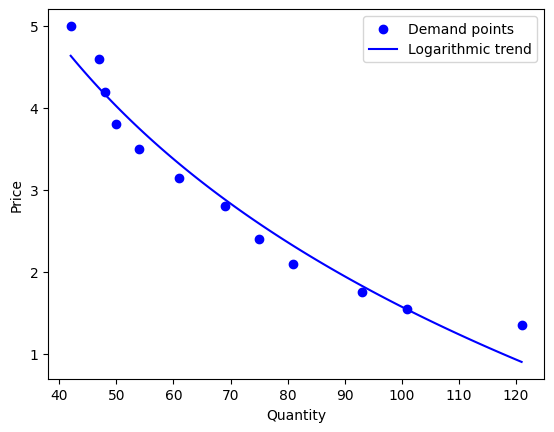

In [4]:
log_D = np.log(df["Demand"])
c, c_log_d = np.polyfit(log_D, df["Price"], 1)
d = np.exp(c_log_d / c)

print(f"c = {c}; d = {d}")
print(f"P = {c:.2f}ln({d:.2f}) + {c:.2f} ln(Q)")

D_range = np.linspace(min(df["Demand"]), max(df["Demand"]), 100)
P_log = c_log_d + c * np.log(D_range)

plt.scatter(df["Demand"], df["Price"], color = "blue", label="Demand points")
plt.plot(D_range, P_log, '-', color = "blue", label="Logarithmic trend")

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.legend()
plt.show()

Analytic function of demand curve is
$$P = -3.53 ln(0.01 Q)$$

## 2. Find market equilibrium point:
$$P = a e^{b Q} = c ln(dQ)$$
$$a e^{b Q} - c ln(dQ) = 0$$

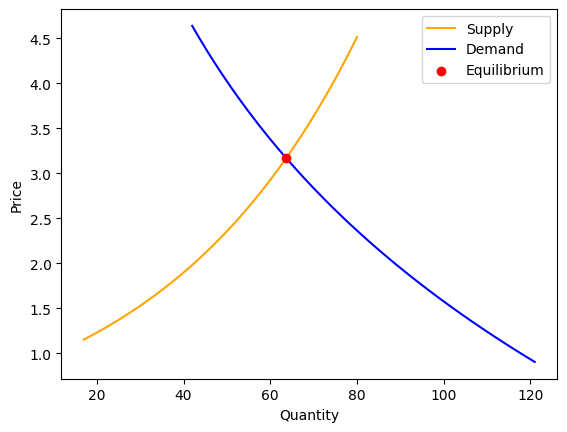

Q* = 63.68074715231092; P* = 3.1677198044790793


In [5]:
def mep_equation(Q):
    return a * np.exp(b * Q) - c * np.log(d * Q)

Q_star = fsolve(mep_equation, x0=60)[0]
P_star = a * np.exp(b * Q_star)

plt.plot(S_range, P_exp, '-', color = "orange", label="Supply")
plt.plot(D_range, P_log, '-', color = "blue", label="Demand")
plt.scatter(Q_star, P_star, color="red", zorder=5, label="Equilibrium")

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.legend()
plt.show()

print(f"Q* = {Q_star}; P* = {P_star}")

Market equilibrium is **stable** if 
$$|E_d| > |E_s|$$
Where 
$$E_d = \frac{dQ}{dP} \frac{P^*}{Q^*}$$
$$P = c \ln(dQ)$$
$$Q = e^\frac{P}{c}/d$$
$$dQ = \frac{1}{cd} e^\frac{P}{c} dP$$

In [12]:
d_Q_d = (1 / (c * d)) * np.exp(P_star / c)
E_d = d_Q_d * (P_star / Q_star)
print(f"E_d = {E_d}")

E_d = -0.8980195687840212


$$P = a e^{b Q}$$
$$\ln P = \ln a + b Q$$
$$Q = \frac{\ln P - \ln a}{b}$$
$$dQ = \frac{1}{bP} dP$$

In [10]:
d_Q_s = 1. / (b * P_star)
E_s = d_Q_s * (P_star / Q_star)
print(f"E_s = {E_s}")

E_s = 0.7247369282874901


$$|-0.9| > |0.7|$$
That means market equilibrium is **stable**.

## 3. Arc elasticity for demand and supply:

In [20]:
for i in range(len(df)-1):
    P1 = df["Price"][i]
    P2 = df["Price"][i+1]

    Qd1, Qd2 = df["Demand"][i], df["Demand"][i+1]
    Qs1, Qs2 = df["Supply"][i], df["Supply"][i+1]

    E_d = ((Qd2 - Qd1) / (P2 - P1)) * ((P1 + P2) / (Qd1 + Qd2))
    E_s = ((Qs2 - Qs1) / (P2 - P1)) * ((P1 + P2) / (Qs1 + Qs2))

    print(f"{i+1}-{i+2}: E_d = {E_d:.2f}, E_s = {E_s:.2f}")

1-2: E_d = -1.31, E_s = 4.23
2-3: E_d = -0.68, E_s = 2.29
3-4: E_d = -0.76, E_s = 0.75
4-5: E_d = -0.58, E_s = 1.31
5-6: E_d = -0.54, E_s = 0.56
6-7: E_d = -1.05, E_s = 0.54
7-8: E_d = -1.16, E_s = 0.43
8-9: E_d = -0.94, E_s = 0.86
9-10: E_d = -0.41, E_s = 0.27
10-11: E_d = -0.23, E_s = 0.29
11-12: E_d = -1.35, E_s = 0.46


## 4. Representation of tax by shifting demand:

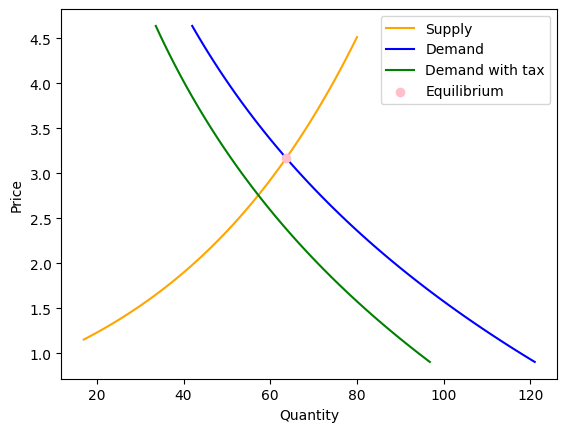

In [27]:
D_range_tax = D_range * 0.8

plt.plot(S_range, P_exp, '-', color = "orange", label="Supply")
plt.plot(D_range, P_log, '-', color = "blue", label="Demand")
plt.plot(D_range_tax, P_log, '-', color = "green", label="Demand with tax")
plt.scatter(Q_star, P_star, color="pink", zorder=5, label="Equilibrium")

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.legend()
plt.show()

* Quantity fals after the tax.
* Consumers pays more.
* Sellers takes less.